# Week 14

Convolutional Neural Network and Residual Nets

In [1]:
!wget -q https://github.com/PSAM-5020-2025S-A/5020-utils/raw/main/src/data_utils.py
!wget -q https://github.com/PSAM-5020-2025S-A/5020-utils/raw/main/src/image_utils.py
!wget -q https://github.com/PSAM-5020-2025S-A/5020-utils/raw/main/src/nn_utils.py
!wget -q https://github.com/PSAM-5020-2025S-A/WK14/raw/main/WK14_utils.py

!wget -qO- https://github.com/PSAM-5020-2025S-A/5020-utils/releases/latest/download/lfw.tar.gz | tar xz

In [2]:
pip install torch

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from torch import nn
from torch import Tensor

from torchvision.models import resnet34, ResNet34_Weights
from torchvision.transforms import v2

from data_utils import LFWUtils, classification_error, display_confusion_matrix
from image_utils import make_image
from nn_utils import get_labels, get_num_params

from WK14_utils import display_activation_grids, display_kernel_grids

### Classification Review

Let's continue exploring the _Labeled Faces in the Wild_ dataset from last week.

We'll start with the multi-layer network we had in the end of class and add some normalization and dropout to help with training.

Just as a review, the steps for setting up a classification (or regression) model are:

- Load dataset and do any kind of pre-pre-processing
- Split data into train/test datasets
- Perform any kind of pre-processing
- Split independent features and classification label and load them into `Tensors`
- Build a NN model
- Set up an optimizer
- Pick a cost/loss function
- Implement an evaluation function and any other kind of visualization that helps quantify/evaluate the model
- Train model
- Evaluate

### Load and split Dataset

The `LFWUtils.train_test_split(0.5)` function gives us some `Python` objects we can use to create our `Tensor`s.

The `pixels` key gives us a list of the images' pixel data, and the `label` key gives us the images' label IDs.

We don't have to do any normalization since the pixels will be in a known, well-defined, range of $[0 \text{ - } 255]$.

The only thing we have to do differently is cast the labels `Tensor` to `long`. This is to ensure the numbers in those `Tensor`s are whole numbers and don't have decimal points.

In [3]:
train, test = LFWUtils.train_test_split(0.5)

### Look at data

We can visualize some of the images, their text labels and label IDs

0 annan


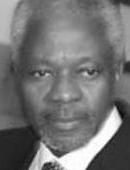

In [4]:
idx = 0

id = train["labels"][idx]
print(id, LFWUtils.LABELS[id])
display(make_image(train["pixels"][idx], width=130))

### Multilayer Perceptron

Let's create a neural network with multiple hidden layers.

In order to keep the training manageable on a cpu, we'll use `PCA` to reduce the dimensions of our input samples.

In [5]:
std = StandardScaler()
pca = PCA(n_components=0.9999)

x_pca_train = pca.fit_transform(std.fit_transform(train["pixels"]))
x_pca_test = pca.transform(std.transform(test["pixels"]))

print(pca.n_components_, pca.explained_variance_ratio_.sum())

x_train = Tensor(x_pca_train)
y_train = Tensor(train["labels"]).long()

x_test = Tensor(x_pca_test)
y_test = Tensor(test["labels"]).long()

x_train.shape

442 0.9999313114185984


torch.Size([445, 442])

In [6]:
model =  nn.Sequential(
  nn.Linear(x_train.shape[1], x_train.shape[1] // 2),
  nn.Sigmoid(),

  nn.Linear(x_train.shape[1] // 2, x_train.shape[1] // 4),
  nn.Sigmoid(),

  nn.Linear(x_train.shape[1] // 4, x_train.shape[1] // 16),
  nn.Sigmoid(),

  nn.Linear(x_train.shape[1] // 16, len(y_train.unique())),
)

learning_rate = 1e-1
optim = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

loss_fn = nn.CrossEntropyLoss()

out = model(x_train)

print("Input shape:", x_train.shape)
print("Output shape:", out.shape)
print("Num Params:", get_num_params(model))

Input shape: torch.Size([445, 442])
Output shape: torch.Size([445, 25])
Num Params: 126020


In [7]:
for e in range(64):
  optim.zero_grad()
  labels_pred = model(x_train)
  loss = loss_fn(labels_pred, y_train)
  loss.backward()
  optim.step()

  if e % 16 == 15:
    train_predictions = get_labels(model, x_train)
    test_predictions = get_labels(model, x_test)
    train_error = classification_error(y_train, train_predictions)
    test_error = classification_error(y_test, test_predictions)
    print(f"Epoch: {e} loss: {loss.item():.4f}, train error: {train_error:.4f}, test error: {test_error:.4f}")

Epoch: 15 loss: 3.1799, train error: 0.9461, test error: 0.9452
Epoch: 31 loss: 3.1683, train error: 0.9281, test error: 0.9338
Epoch: 47 loss: 3.1593, train error: 0.8697, test error: 0.8973
Epoch: 63 loss: 3.1444, train error: 0.8247, test error: 0.8493


train error: 0.8247
test error 0.8493


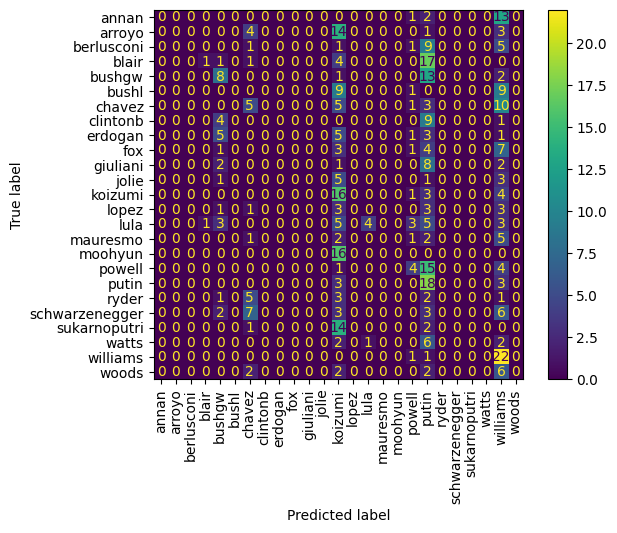

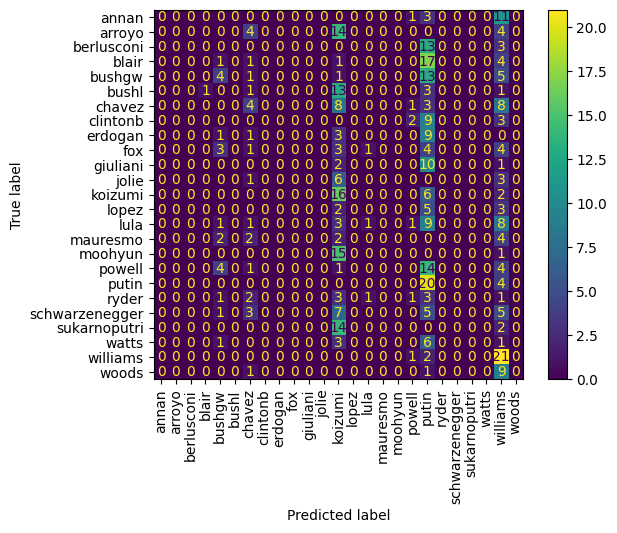

In [8]:
train_predictions = get_labels(model, x_train)
test_predictions = get_labels(model, x_test)

print("train error:", f"{classification_error(y_train, train_predictions):.4f}")
print("test error", f"{classification_error(y_test, test_predictions):.4f}")

display_confusion_matrix(y_train, train_predictions, display_labels=LFWUtils.LABELS)
display_confusion_matrix(y_test, test_predictions, display_labels=LFWUtils.LABELS)

### Interpretation

The result is mostly the same.

We did add layers, but the network didn't need any extra neurons to do well on the training data.

It needs help with the testing data, or, another way to say this is: it needs help generalizing without memorizing.

### Make It Harder

Neural network models can seem simple to explain in a general sense: they're long and wide computation graphs made up of simple operations that have been tuned to achieve a specific task. Once they're training, or trained, their details and specificities are a little less easy to describe. It's hard to know exactly what each neuron is doing, and what part of the computation they are responsible for. We can train the same network, with the same parameters, using the same input data, and end up with wildly different results.

This is one reason why it's hard to debug a network when it doesn't seem to be learning properly, or when it starts to overfit and memorize the training data. Which neurons do we tune ?

One common situation that can lead to overfitting is when a network ends up with parameters that make it perform well on the training data without really activating all of its neurons. This is usually what is happening if adding layers to a network doesn't improve its performance.

One set of strategies for improving neural network training in these cases involves making the training process harder than it has to be. It's like we're challenging the neural network to learn more than it has, so that later it has an easier time with the regular data.

#### Dropout

One simple technique to achieve this is to add `Dropout` layers to our network. A `Dropout` layer is a layer of neurons that don't perform any mathematical operation, but are selectively dropped out of the network randomly during training. This has the effect of randomly changing the network's architecture during training and preventing the network from becoming too reliant on specific neurons. Instead, it encourages the network to learn more robust features by activating more diverse sets of neurons.

<img src="./imgs/dropout.jpg" width="800px"/>

#### Activation Normalization

Another technique that is used to keep our neural networks from memorizing data has to do with the range of the values that get passed between its inner layers.

Input data coming into the network is most likely normalized, but after the first layer, the network weights might really change the distribution of the data as it flows through the network. Moreover, individual batches with different input value distributions can bias the network towards certain goals.

<img src="./imgs/norm_activation.jpg" width="720px"/>

#### Batch Normalization

One way to handle these situations is to normalize the data as it passes through the network. Batch Normalization is the process of normalizing the activations of our network by using the mean and standard deviation of an activation neuron across a batch. The result is that the activations between batches become more similar. Batch normalization is dependent on batch size, so it's not effective for small batches.

<img src="./imgs/norm_batch.jpg" width="720px"/>

#### Layer Normalization

Another form of inner-network normalization can be added to make sure no individual layer overpowers the network with activation values that are too large or too small.

Layer Normalization scales activations using the mean and standard deviation of all activations across a layer. It's effective for sequence models like RNNs and Transformers, and for scenarios with small batch sizes, and doesn't require a large batch to get a good estimate for mean and standard deviation. 

<img src="./imgs/norm_layer.jpg" width="720px"/>

In [9]:
model =  nn.Sequential(
  nn.Dropout(0.35),
  nn.Linear(x_train.shape[1], x_train.shape[1] // 2),
  # nn.LayerNorm(x_train.shape[1] // 2),
  nn.Sigmoid(),
  # nn.BatchNorm1d(x_train.shape[1] // 2),

  nn.Dropout(0.35),
  nn.Linear(x_train.shape[1] // 2, x_train.shape[1] // 4),
  # nn.LayerNorm(x_train.shape[1] // 4),
  nn.Sigmoid(),
  # nn.BatchNorm1d(x_train.shape[1] // 4),

  nn.Dropout(0.35),
  nn.Linear(x_train.shape[1] // 4, x_train.shape[1] // 16),
  # nn.LayerNorm(x_train.shape[1] // 16),
  nn.Sigmoid(),
  # nn.BatchNorm1d(x_train.shape[1] // 16),

  nn.Dropout(0.35),
  nn.Linear(x_train.shape[1] // 16, len(y_train.unique())),
)

learning_rate = 1e-1
optim = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

loss_fn = nn.CrossEntropyLoss()

out = model(x_train)

print("Input shape:", x_train.shape)
print("Output shape:", out.shape)
print("Num Params:", get_num_params(model))

Input shape: torch.Size([445, 442])
Output shape: torch.Size([445, 25])
Num Params: 126020


In [10]:
for e in range(64):
  optim.zero_grad()
  labels_pred = model(x_train)
  loss = loss_fn(labels_pred, y_train)
  loss.backward()
  optim.step()

  if e % 16 == 15:
    train_predictions = get_labels(model, x_train)
    test_predictions = get_labels(model, x_test)
    train_error = classification_error(y_train, train_predictions)
    test_error = classification_error(y_test, test_predictions)
    print(f"Epoch: {e} loss: {loss.item():.4f}, train error: {train_error:.4f}, test error: {test_error:.4f}")

Epoch: 15 loss: 3.1952, train error: 0.9348, test error: 0.9452
Epoch: 31 loss: 3.1696, train error: 0.8921, test error: 0.8973
Epoch: 47 loss: 3.1617, train error: 0.8494, test error: 0.8790
Epoch: 63 loss: 3.1473, train error: 0.8315, test error: 0.8607


### Interpretation

The train and test eval function diverged, but both keep decreasing, so this might be ok.

In the end, the network seems capable of learning for longer and while the classification error for the test dataset doesn't keep up with the error in the train dataset, it does perform better.

train error 0.8315
test error 0.8607


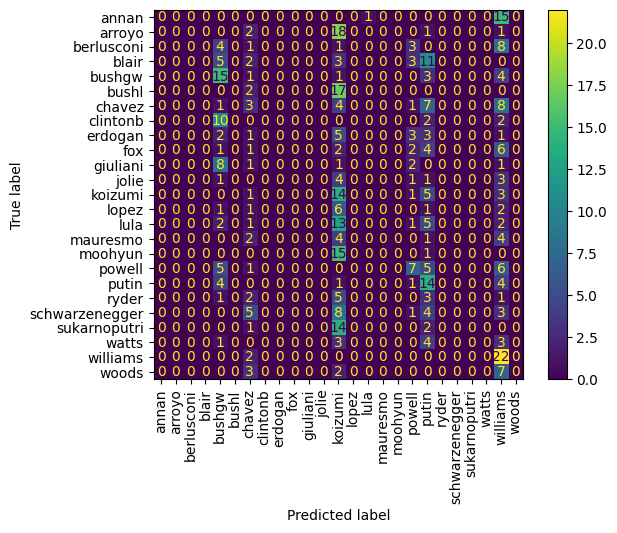

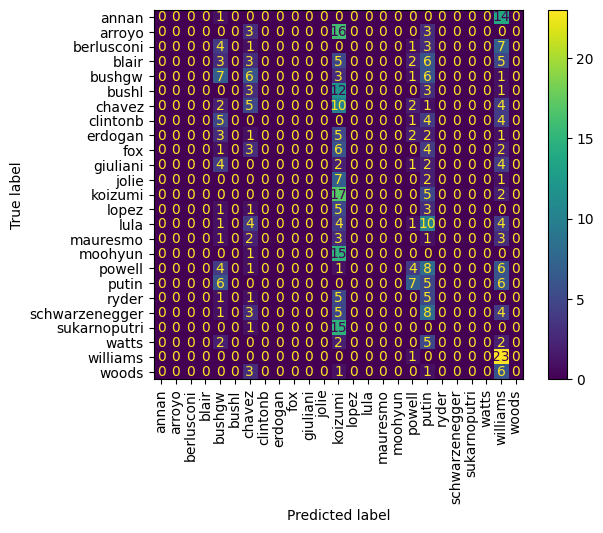

In [11]:
train_predictions = get_labels(model, x_train)
test_predictions = get_labels(model, x_test)

print("train error", f"{classification_error(y_train, train_predictions):.4f}")
print("test error", f"{classification_error(y_test, test_predictions):.4f}")

display_confusion_matrix(y_train, train_predictions, display_labels=LFWUtils.LABELS)
display_confusion_matrix(y_test, test_predictions, display_labels=LFWUtils.LABELS)

## Spatial Information

Our fully-connected layers do ok for this dataset, but they are not very efficient.

There are $2$ main problems with using this approach to extract information about images:

### Every pixel is connected to every other pixel

Consider the first layer after the input layer: every neuron gets information about every pixel. This means that the content at the top-left corner of our image is connected to the content at the bottom-right corner, which is inefficient. We probably don't need our network to consider the entire content of the image at once in order to make decisions. It jumbles the pixel order and just makes the process harder. We might be better off telling our network to consider groups of neighboring pixels, since it's most likely for visual features to come from pixels that are near each other. In other words, we want to extract and preserve some kind of relative _Locality_ from our pixels.

### Not all Arnolds are the same

Let's say our network learned how to classify an Arnold Schwarzenegger that's closer to the left side of the image. If it wants to detect Arnolds on the right side of the image, or towards the top, it has to learn how to activate neurons that are associated with those sections of the image. This is also inefficient because it has to relearn to detect the same thing again, just because it's somewhere else in the image.

Again, what we would like to do is group neighboring pixels, and have the groups go through similar neurons, so that any kind of learning can be applied independent of where shapes are located in the image. The technical name for this property is _Translation Invariance_.

## Convolutions

We could try to come up with our own architecture and write some code for a neural network that doesn't fully connect our pixels, but rather considers neighboring regions of our image in groups of neurons.

But, luckily, some maths combined with intuition from old-school systems and feature engineering can help us here.

There's a type of mathematical operation called a convolution that combines $2$ arbitrary functions into a new function that basically has information about all the possible combinations of inputs for the $2$ original functions.

<!-- The math looks like this for the $1D$ continuous case:<br> -->
<!-- $\displaystyle (f * g)(\tau) = \int_{-\infty}^{\infty}{f(\tau)\ g(1 - \tau)\ d\tau}$ -->

The math looks like this for the $1D$ case:<br>
$\displaystyle (f * g)[n] = \sum_{k=-K}^{K}{f[k]\ \ g[n - k]}$


<br>And the $2D$ case:<br>
$\displaystyle (f * g)[n_x, n_y] = \sum_{k_x=-K}^{K}{\sum_{k_y=-K}^{K}{f[k_x, k_y]\ \ g[n_x - k_x, n_y - k_y]}}$

For the practical, intuitive, definition of this operation when dealing with images, $f[\ ]$ is an image tensor and $g[\ ]$ can be different, but specific, combinations of numbers organized into $2D$ matrices called kernels.

When we _convolve_ the image with the kernel, we calculate every possible overlap of our kernel with the image and, depending on the numbers we choose for the kernel, can extract different types of features from our pixels.

<!-- <img src="./imgs/kernel_slide.jpg" height="256px"/> -->
<img src="https://i.postimg.cc/wMzHtFnJ/kernel-slide.jpg" height="256px"/>

[SOME ANIMATIONS](https://hannibunny.github.io/mlbook/neuralnetworks/convolutionDemos.html)


Classic image processing kernels for sharpening an image and extracting edges:

<!-- <img src="./imgs/image_kernels.jpg" height="300px"/> -->
<img src="https://i.postimg.cc/fTKWdnzb/image-kernels.jpg" height="300px"/>

The nice thing about these kernels is that they operate on neighboring pixels by default, so they already take into account the _locality_ of the features they're trying to detect.

We can now set up a neural network that is a collection of $2D$ image kernels, and let our training algorithm learn parameters for these kernels based on the training data. We don't have to specify that we want an edge-detection kernel, or a curved-shape kernel, or a horizontal blur kernel... the network will learn the kernels that it needs.

And, since the same kernel slides over an entire image during convolution, once the network learns to extract lines on the left side of the image, it also knows how to extract lines on the right side of the image, or on top, or anywhere else. The parameters to the kernel are the same, they just get applied to different neighborhoods of pixels.

If we combine our bank of kernels with another operation to reduce the size of our image as it moves through the network, we can create a type of dynamic filtering that detects whether certain features are present on our image.

<!-- <img src="./imgs/cnn_layers.jpg" height="320px"/> -->
<img src="https://i.postimg.cc/rpdq7DSd/cnn-layers.jpg" height="320px"/>

Then, after we have reduced our feature maps to a small-enough shape we ca use fully-connected layers to finalize our classification.

<!-- <img src="./imgs/cnn_fc.jpg" height="320px"/> -->
<img src="https://i.postimg.cc/XYYjcHqk/cnn-fc.jpg" height="320px"/>

### New Network, New Shape

Right now our input samples are lists of pixels, organized in a `tensor` of shape $(1, 22100)$. In order to use the convolution layers we actually need the images in a $2D$ tensor of shape $(170, 130)$.

CNNs are even more particular about channels: we not only have to be explicit about the number of channels on our images, but this info also has to be in the first dimension of our image tensors.

So, instead of working with the original image shape where each pixel keeps the values for its channels together, like:<br>
$H \times W \times C$ (`height` by `width` by `channel`)

we now have to use a `tensor` made up of single-channel images: all the RED values, then all the GREEN values, then all the BLUE values... so a $3D$ `tensor` of shape: $C \times H \times W$. For our `LFW` images this is $(1, 170, 130)$.

The [`permute()`](https://pytorch.org/docs/stable/generated/torch.permute.html) or [`movedim()`](https://pytorch.org/docs/stable/generated/torch.movedim.html#torch.movedim) functions can be used to reorganize the order of a `tensor`'s dimensions.

In the end, our dataset should be in a `tensor` of shape:<br>
$N \times C \times H \times W$ (`samples`, `channels`, `height`, `width`).

In [12]:
train, test = LFWUtils.train_test_split(0.5)

We're working with grayscale images in this exercise, but the code below should also work for `RGB` images.

In [13]:
iw,ih = LFWUtils.IMAGE_SIZE
n_channels = len(train["pixels"][0][0]) if type(train["pixels"][0][0]) == list else 1
n_samples = len(train["pixels"])

x_train = Tensor(train["pixels"]).reshape(n_samples, LFWUtils.IMAGE_HEIGHT, LFWUtils.IMAGE_WIDTH, n_channels).permute(0,3,1,2)
x_test = Tensor(test["pixels"]).reshape(-1, LFWUtils.IMAGE_HEIGHT, LFWUtils.IMAGE_WIDTH, n_channels).movedim(-1, 1)

y_train = Tensor(train["labels"]).long()
y_test = Tensor(test["labels"]).long()

In [14]:
print("Dataset Samples")
print("\tTrain:", len(x_train))
print("\tTest:", len(x_test))

print("\nDataset Shape:")
print(f"\tTrain:", list(x_train.shape))
print(f"\tTtest:", list(x_test.shape))

print("\nSample Shape:")
print(f"\tTrain:", list(x_train[0].shape))
print(f"\tTest:", list(x_test[0].shape))

Dataset Samples
	Train: 445
	Test: 438

Dataset Shape:
	Train: [445, 1, 170, 130]
	Ttest: [438, 1, 170, 130]

Sample Shape:
	Train: [1, 170, 130]
	Test: [1, 170, 130]


### Check Image

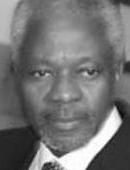

In [15]:
idx = 0
img_t = x_train[idx].permute(1,2,0).reshape(-1, x_train.shape[1])
display(make_image(img_t, width=x_train.shape[3]))

### Define CNN Model

This is how we define a convolution layer:

`nn.Conv2d(Cin, Cout, kernel_size)`

Where `Cin` is the number of input channels, `Cout` is output channels, and `kernel_size` the width of our kernel.

We should still normalize the computations by batch, but this time using the $2D$ version of `BatchNorm()`, and after activation we perform the `MaxPool` operation, which takes the largest value in a $2 \times 2$ region of our activations and condenses them into denser representation of features.

In [16]:
linear_length = 70848

model = nn.Sequential(
  nn.Conv2d(1, 32, 7),
  nn.BatchNorm2d(32),
  nn.ReLU(),
  nn.MaxPool2d(3),

  nn.Flatten(),

  nn.Dropout(0.35),
  nn.Linear(linear_length, len(LFWUtils.LABELS)),
)

learning_rate = 1e-3
optim = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

loss_fn = nn.CrossEntropyLoss()

out = model(x_train)

print("Input shape:", x_train.shape)
print("Output shape:", out.shape)
print("Parameters:", get_num_params(model))

Input shape: torch.Size([445, 1, 170, 130])
Output shape: torch.Size([445, 25])
Parameters: 1772889


In [17]:
for e in range(32):
  optim.zero_grad()
  labels_pred = model(x_train)
  loss = loss_fn(labels_pred, y_train)
  loss.backward()
  optim.step()

  if e % 4 == 3:
    train_predictions = get_labels(model, x_train)
    test_predictions = get_labels(model, x_test)
    train_error = classification_error(y_train, train_predictions)
    test_error = classification_error(y_test, test_predictions)
    print(f"Epoch: {e} loss: {loss.item():.4f}, train error: {train_error:.4f}, test error: {test_error:.4f}")

Epoch: 3 loss: 2.4804, train error: 0.9213, test error: 0.9338
Epoch: 7 loss: 5.3946, train error: 0.3281, test error: 0.6256
Epoch: 11 loss: 1.9688, train error: 0.2292, test error: 0.5731
Epoch: 15 loss: 1.2509, train error: 0.1079, test error: 0.5183
Epoch: 19 loss: 0.6316, train error: 0.0517, test error: 0.4475
Epoch: 23 loss: 0.2073, train error: 0.0180, test error: 0.4018
Epoch: 27 loss: 0.0898, train error: 0.0090, test error: 0.3950
Epoch: 31 loss: 0.0576, train error: 0.0067, test error: 0.4132


## Transfer Learning

The CNN architecture is so stable that models can be made to be very deep, some with $100\text{s}$ of layers.

The internal layers of these models are so abstract and generic that once a model has been trained on millions of data samples (images), it learns and retains information not only about the images on the dataset, but any visual pattern that it learned in the process.

It's not uncommon to use a previously trained model for a similar-but-different project, even if the images have nothing in common. Generic information about images can be transferred to new datasets and problem spaces.

<!-- <img src="./imgs/resnet_activation_00.jpg" height="300px" /> -->
<img src="https://i.postimg.cc/tR3twzmz/resnet-activation-00.jpg" height="300px" />

<!-- <img src="./imgs/resnet_activation_01.jpg" height="300px" /> -->
<img src="https://i.postimg.cc/hPKbB7kR/resnet-activation-01.jpg" height="300px" />

<!-- <img src="./imgs/resnet_activation_02.jpg" height="300px" /> -->
<img src="https://i.postimg.cc/15M053Sn/resnet-activation-03.jpg" height="300px" />

### Residual Networks

There are a couple of families of CNN networks that get used as the starting point for many different types of visual models (and also audio and text). One such architecture is [ResNet](https://arxiv.org/abs/1512.03385).

ResNet comes in a few sizes/depths, and PyTorch has at least [5 pre-trained ResNet models](https://pytorch.org/hub/pytorch_vision_resnet/) that we can use.

These PyTorch ResNet models were trained on the [ImageNet](https://image-net.org/download.php) dataset. This dataset has $1\text{,}281\text{,}167$ training images and classifies objects into $1\text{,}000$ classes.

We'll use the `ReNet34` model, which is not the largest, but will fit nicely into small GPUs.

<!-- <img src="./imgs/resnet34_00.jpg" width="900px" /> -->
<img src="https://i.postimg.cc/XNc8xdqy/resnet34-00.jpg" width="900px" />

<!-- <img src="./imgs/resnet34_01.jpg" width="900px" /> -->
<img src="https://i.postimg.cc/hP20Rn9D/resnet34-01.jpg" width="900px" />


### Instantiating ResNet

Is easy:

In [18]:
model = resnet34(weights=ResNet34_Weights.DEFAULT)
display(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Adjust inputs

From https://pytorch.org/hub/pytorch_vision_resnet/:

_All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225]._

We can use `PyTorch` transformation functions to achieve this, but this means that now we'll have some transformations that always have to happen and some that only happen in the training dataset.

In [19]:
res_transforms = v2.Compose([
  v2.ToDtype(torch.uint8),
  v2.Resize(224),
  v2.Grayscale(3),
  v2.ToDtype(torch.float32, scale=True),
  v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [20]:
#x_train_res = res_transforms(x_train).to("cuda")
#x_test_res = res_transforms(x_test).to("cuda")

x_train_res = res_transforms(x_train)
x_test_res = res_transforms(x_test)

print("Training dataset shape:", x_train_res.shape)
print("Image shape:", x_train_res[0].shape)

Training dataset shape: torch.Size([445, 3, 292, 224])
Image shape: torch.Size([3, 292, 224])


In [21]:
x_train_res[0].min(), x_train_res[0].max()

(tensor(-1.9295), tensor(2.6400))

In [22]:
model.fc = nn.Linear(model.fc.in_features, len(LFWUtils.LABELS))
#model = model.to("cuda")

model = model

learning_rate = 5e-3
optim = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

loss_fn = nn.CrossEntropyLoss()

out = model(x_train_res[::3])

print("Input shape:", x_train_res.shape)
print("Output shape:", out.shape)
print("Parameters:", get_num_params(model))

Input shape: torch.Size([445, 3, 292, 224])
Output shape: torch.Size([149, 25])
Parameters: 21297497


In [ ]:
#y_train = y_train.to("cuda")
#y_test = y_test.to("cuda")

y_train = y_train
y_test = y_test

: 

In [ ]:
batch_step = 3

for e in range(16):
  model.train()
  for batch_start in range(batch_step):
    optim.zero_grad()
    labels_pred = model(x_train_res[batch_start::batch_step])
    loss = loss_fn(labels_pred, y_train[batch_start::batch_step])
    loss.backward()
    optim.step()

  if e % 4 == 3:
    train_predictions = get_labels(model, x_train_res)
    test_predictions = get_labels(model, x_test_res)
    train_error = classification_error(y_train.cpu(), train_predictions)
    test_error = classification_error(y_test.cpu(), test_predictions)
    print(f"Epoch: {e} loss: {loss.item():.4f}, train error: {train_error:.4f}, test error: {test_error:.4f}")

In [ ]:
train_predictions = get_labels(model, x_train_res)
test_predictions = get_labels(model, x_test_res)
train_error = classification_error(y_train.cpu(), train_predictions)
test_error = classification_error(y_test.cpu(), test_predictions)
print(f"train error: {train_error:.4f}, test error: {test_error:.4f}")

display_confusion_matrix(y_train.cpu(), train_predictions, display_labels=LFWUtils.LABELS)
display_confusion_matrix(y_test.cpu(), test_predictions, display_labels=LFWUtils.LABELS)

NameError: name 'x_train_res' is not defined

### Visualize Layers

That worked really well. The information learned by the `ResNet` network on 1 million images seems to transfer to our classification of faces and we can leverage its pattern-recognition layers to build a more accurate model in a short amount of time.

Let's take a look at some of the filtered images in our `ResNet` model. We can do this with an untrained model, but it's better to look at one that has been recently trained.

When we displayed the model layers above we saw that the model has $4$ main groups of convolution layers. The further down the model we go, the smaller the images are, and the more abstract the activation patterns will be.

At the very last layer we might have $512$ _images_ that are only $4 \times 4$ pixels, but light-up under very specific conditions, like: is there a bird in the image ? is there a face ?

To see slightly larger images we'll look at some activations on layers $1$ and $2$.

We'll use the `hook` mechanism from `PyTorch` to add some auxiliary logic to the layers we are interested in looking at. This allows us to run some extra code on the layers inputs and outputs every time it processes an image.

Our `hook` function will just save the layers input and output tensors to external dictionaries that we cn visualize later.

In [ ]:
activations_in = {}
activations_out = {}
layer_kernels = {}

def get_activation(name):
  def hook(model, input, output):
    if name not in layer_kernels:
      layer_kernels[name] = model.weight.detach()
    activations_in[name] = input[0].detach()
    activations_out[name] = output.detach()
  return hook

model.conv1.register_forward_hook(get_activation('conv1'))
model.layer1[1].conv2.register_forward_hook(get_activation('layer1.1.conv2'))
model.layer1[2].conv2.register_forward_hook(get_activation('layer1.2.conv2'))
model.layer2[0].conv2.register_forward_hook(get_activation('layer2.0.conv2'))
model.layer4[0].conv2.register_forward_hook(get_activation('layer4.0.conv2'))
model.layer4[2].conv2.register_forward_hook(get_activation('layer4.2.conv2'))
model = model.to(mdevice)

NameError: name 'mdevice' is not defined

Once we have our `hook` in place we have to pass some data through the network so it saves the inputs and outputs for us.

In [ ]:
with torch.no_grad():
  model(x_train_res[0:128].to("cuda"))

Now we can display activations for specific images in the processed batch:

In [ ]:
img_idx = 0
channel_idx = 0

img_t = x_train[img_idx, channel_idx]

display(make_image(img_t, width=img_t.shape[-1]))
display_activation_grids(activations_out, img_idx)

And we can also visualize the kernel values in each layer.

These are tiny $3 \times 3$ or $7 \times 7$ convolution kernels that get multiplied to filter the images.

Other than the first one, where the kernels actually acted on 3-channel layers, the colors on the other kernels is artificial. They're the result of combining the kernels into groups of $3$, but in reality they are 64-channel kernels.

In [ ]:
display_kernel_grids(layer_kernels)